# 04. Modelagem Econométrica: Regressão Linear Simples e Múltipla das Rotas Líderes

**Documentação da Etapa**
* **Objetivo da etapa:** Estimar e comparar modelos econométricos para as 6 rotas comerciais líderes (Top 1) dos municípios polo da Baixada Santista (Cubatão, Guarujá e Santos), avaliando a relação entre faturamento comercial e volume físico movimentado.
* **Abordagem metodológica em duas etapas:**
  1. **Regressões Lineares Simples Estratificadas:** Modelagem individual por rota líder ($\text{Valor FOB} \sim \text{Volume}$) para estimar a sensibilidade direta e o preço médio por tonelada de cada combinação produto-país-município-fluxo.
  2. **Regressão Linear Múltipla Consolidada:** Integração de todas as rotas líderes em um único modelo com variáveis *dummy* categóricas ($\text{Valor FOB} \sim \text{Volume} + \text{Fluxo} + \text{Município} + \text{Rota}$) para controlar simultaneamente efeitos de escala, pauta e polo logístico.
* **Dados de entrada:** Base mensal agregada das rotas líderes (`data/processed/df_sazonal_lideres.csv`).

### 0. Configurações e Carregamento de Dados

In [5]:
# ==============================================================================
# Setup, Carregamento de Bibliotecas, Funções e Base de Dados
# ==============================================================================
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(scales)
library(fs)
library(lmtest)

# 1. Determina dinamicamente o caminho da raiz do projeto
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) == "notebooks", path_dir(caminho_atual), caminho_atual)

# 2. Carrega as funções do script modular de regressão linear
source(path(raiz_projeto, "R", "regressao_linear.R"))

# 3. Carrega a base sazonal das rotas líderes (Top 1)
caminho_csv <- path(raiz_projeto, "data", "processed", "df_sazonal_lideres.csv")
df_sazonal_lideres <- read_csv2(caminho_csv, show_col_types = FALSE)

# 4. Configuração visual de números no console
options(scipen = 999, digits = 3)

cat(sprintf("Ambiente configurado com sucesso! Base carregada com %d agregações mensais.\n", nrow(df_sazonal_lideres)))

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Ambiente configurado com sucesso! Base carregada com 481 agregações mensais.


## 1. Regressão Linear Simples por Rota Líder

### Formulação Teórica

A **Regressão Linear Simples** busca estimar a relação funcional direta entre o faturamento comercial e o volume físico movimentado via Mínimos Quadrados Ordinários (OLS):

$$\text{Valor FOB}_t = \beta_0 + \beta_1 \cdot \text{Volume}_t + \varepsilon_t$$

* **$\text{Valor FOB}_t$ (Variável Dependente, $Y$):** Faturamento comercial FOB mensal em Milhões de US\$.
* **$\text{Volume}_t$ (Variável Independente, $X$):** Volume físico movimentado em milhares de toneladas ($k\text{ ton}$).
* **$\beta_0$ (Intercepto):** Valor base esperado quando o volume tende a zero.
* **$\beta_1$ (Coeficiente Angular):** Preço unitário médio estimado da rota ($\text{Milhões US\$ / } k\text{ ton}$, correspondente a $\text{US\$/kg}$ ou milhares de $\text{US\$/ton}$).
* **$\varepsilon_t$ (Termo de Erro):** Resíduo estocástico do modelo.



### Aplicação nas Rotas Líderes
O modelo é ajustado de forma segmentada para cada uma das **6 rotas líderes (Top 1)** identificadas pelo princípio de Pareto nos fluxos de exportação e importação dos municípios de Cubatão, Guarujá e Santos.

In [6]:
# Ajuste dos modelos OLS simples para todas as rotas líderes
regressao_simples <- ajustar_regressao_top1_rotas(df_sazonal_lideres)

# Exibição das métricas consolidadas
regressao_simples$metricas |>
  mutate(`Descrição Curta` = str_trunc(`Descrição SH4`, 25)) |>
  select(
    Fluxo, Município, País, `Produto` = `Descrição Curta`,
    N, `β₀ (Intercepto)` = Intercepto_b0, 
    `β₁ (Preço Médio Estimado)` = Inclinacao_b1_preco_medio,
    `R²` = R2, `R² Ajustado` = R2_Ajustado, 
    `RMSE (M$ FOB)` = RMSE_Milhoes_FOB, `p-valor` = p_valor
  ) |>
  as.data.frame()

Fluxo,Município,País,Produto,N,β₀ (Intercepto),β₁ (Preço Médio Estimado),R²,R² Ajustado,RMSE (M$ FOB),p-valor
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Exportação,Cubatão - SP,China,"Soja, mesmo triturada",78,-0.718,0.4729,0.925,0.924,5.222,<0.001
Exportação,Guarujá - SP,China,"Soja, mesmo triturada",76,-0.005,0.4458,0.891,0.890,15.661,<0.001
Exportação,Santos - SP,China,"Soja, mesmo triturada",86,1.032,0.4383,0.917,0.916,23.342,<0.001
Importação,Cubatão - SP,Chile,Sal (incluídos o sal d...,71,0.173,0.0198,0.822,0.820,0.155,<0.001
Importação,Guarujá - SP,Estados Unidos,Hidróxido de sódio (so...,82,-0.127,0.1761,0.775,0.772,1.518,<0.001
Importação,Santos - SP,Argentina,Trigo e mistura de tri...,88,0.469,0.2626,0.757,0.754,3.174,<0.001


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall,

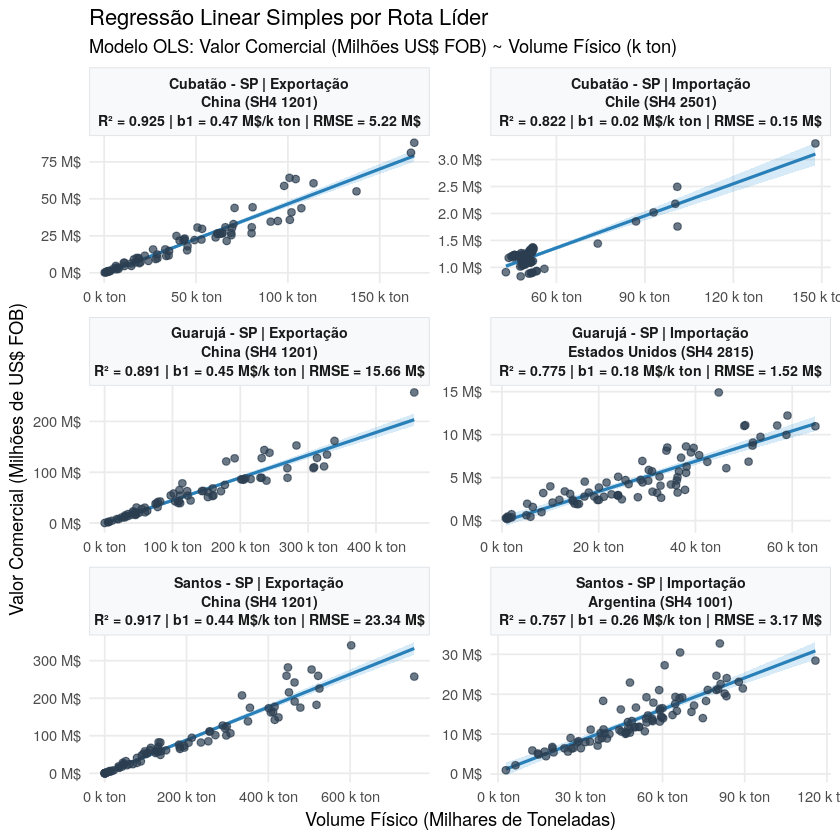

In [7]:
# Visualização dos diagramas de dispersão com retas OLS simples ajustadas (Valor FOB ~ Volume)
plotar_regressao_top1_rotas(regressao_simples)

Os resultados das regressões lineares simples demonstram que o faturamento comercial (Valor FOB) e o volume físico movimentado possuem uma **associação linear positiva (crescente) e de forte intensidade** em todas as 6 rotas líderes analisadas. Essa relação direta é evidenciada pelos coeficientes angulares ($\beta_1$) positivos e estatisticamente significativos ($p < 0{,}001$), indicando que cada incremento no volume físico acarreta uma elevação consistente no valor financeiro transacionado. Além disso, os elevados coeficientes de determinação obtidos — variando de $R^2 = 0{,}757$ na importação de trigo em Santos até $R^2 = 0{,}925$ na exportação de soja em Cubatão — comprovam que a maior parte da variabilidade do faturamento em dólares é explicada diretamente pela escala do volume transportado, refletindo alta previsibilidade de preços médios e forte estabilidade na precificação de cada mercadoria ao longo do período observado.

### Diagnóstico Gráfico de Resíduos (OLS Simples)

Avaliação dos pressupostos clássicos da regressão linear simples (homocedasticidade, linearidade e ausência de padrões residuais sistemáticos):

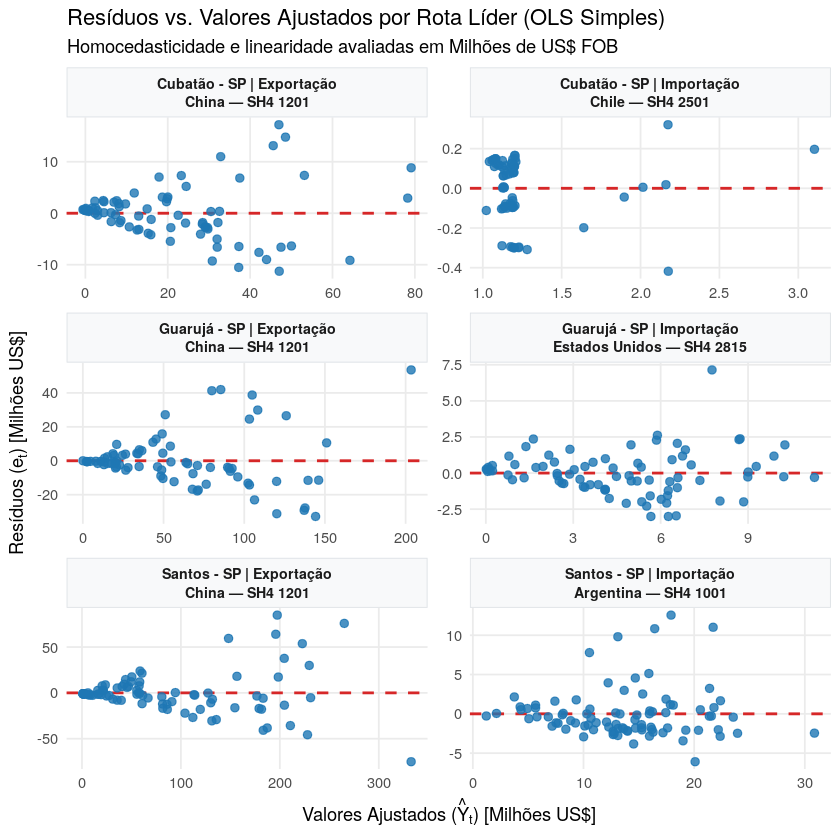

In [8]:
# Extração e consolidação dos resíduos
df_diag_simples <- obter_dados_diagnostico_rotas(regressao_simples)

# Painel: Resíduos vs. Valores Ajustados
plotar_todos_residuos_vs_ajustados(df_diag_simples)

## 2. Regressão Linear Múltipla Consolidada com Interações

### Formulação Teórica

Para integrar toda a base das rotas líderes e modelar conjuntamente os diferentes preços médios e pontos de partida de cada rota sem incorrer em multicolinearidade exata, ajusta-se um modelo de **Regressão Linear Múltipla com Interações**:

$$\widehat{\text{Valor FOB}} = \beta_0 + \beta_1 \cdot (\text{Volume}) + \sum_{i=2}^{6} \gamma_i \cdot D_{\text{Rota}_i} + \sum_{i=2}^{6} \delta_i \cdot (\text{Volume} \times D_{\text{Rota}_i})$$

* **$\beta_0$ (Intercepto de Referência):** Faturamento base esperado da rota de referência (`Cubatão | Exportação | China | Soja`) quando o volume tende a zero.
* **$\beta_1$ (Inclinação de Referência):** Preço unitário médio estimado para a rota de referência ($\text{US\$/kg}$ ou milhares de $\text{US\$/ton}$).
* **$D_{\text{Rota}_i}$:** Variáveis *dummy* indicadoras para cada uma das outras 5 rotas líderes ($i = 2, \dots, 6$) em relação à categoria base.
* **$\gamma_i$ (Diferencial de Intercepto):** Ajuste no intercepto da rota $i$ em relação ao intercepto da rota base $\beta_0$.
* **$\delta_i$ (Diferencial de Inclinação / Preço Médio):** Ajuste no preço unitário médio por tonelada da rota $i$ em relação à inclinação base $\beta_1$.
* **$(\text{Volume} \times D_{\text{Rota}_i})$:** Termos de interação que permitem que cada rota líder possua sua própria inclinação (preço por tonelada) dentro de uma única equação consolidada.


### Aplicação da Regressão Linear Múltipla

In [9]:
# Ajuste do modelo consolidado com interação
regressao_multipla <- ajustar_regressao_multipla_consolidada(df_sazonal_lideres)

# 1. Métricas globais
regressao_multipla$metricas_globais

N_Observacoes,R2,R2_Ajustado,RMSE_Milhoes_FOB,F_Estatistica,p_valor_Global
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
481,0.945,0.944,12,734,<0.001


In [10]:
# 2. Tabela de coeficientes e interações
regressao_multipla$coeficientes |>
  select(Termo, Estimativa, Erro_Padrao, t_valor, `p-valor` = p_valor_formatado) |>
  as.data.frame()

Termo,Estimativa,Erro_Padrao,t_valor,p-valor
<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),-0.7183,2.1260,-0.338,0.73562
Volume (k ton),0.4729,0.0352,13.430,< 0.001
Rota: Cubatão - SP | Importação | Chile | Sal (incluíd...,0.8911,5.3193,0.168,0.86704
"Rota: Guarujá - SP | Exportação | China | Soja, mesmo ...",0.7133,3.1337,0.228,0.82005
Rota: Guarujá - SP | Importação | Estados Unidos | Hidróxido de...,0.5911,3.3638,0.176,0.86058
"Rota: Santos - SP | Exportação | China | Soja, mesmo ...",1.7500,2.8858,0.606,0.54452
Rota: Santos - SP | Importação | Argentina | Trigo e mist...,1.1873,3.9281,0.302,0.76258
[Interação] Volume × Cubatão - SP | Importação | Chile | Sal (incluíd...,-0.4531,0.0924,-4.904,< 0.001
"[Interação] Volume × Guarujá - SP | Exportação | China | Soja, mesmo ...",-0.0271,0.0378,-0.718,0.47333


#### Exemplo Prático de Interpretação: Rota de Importação de Trigo (Santos)

Para ilustrar como os 12 coeficientes estimados pelo modelo múltiplo consolidado se traduzem na reta ajustada de uma rota específica, analisamos a rota de **Importação de Trigo em Santos (origem Argentina)**:

##### a. Coeficientes Extraídos da Tabela
* **$\beta_0$ (Intercepto Base - Soja Cubatão):** $-0{,}7183$
* **$\beta_1$ (Inclinação Base - Soja Cubatão):** $+0{,}4729$
* **$\gamma_{\text{Trigo}}$ (Linha `Rota: Santos | Importação | Argentina...`):** $+1{,}1873$
* **$\delta_{\text{Trigo}}$ (Linha `[Interação] Volume × Santos | Importação | Argentina...`):** $-0{,}2104$

---

##### b. Substituição na Equação Geral do Modelo
Para a rota do Trigo de Santos, a variável dummy $D_{\text{Trigo}} = 1$ e todas as demais variáveis dummy assumem valor $0$:

$$\widehat{\text{Valor FOB}} = \underbrace{(-0{,}7183)}_{\beta_0} + \underbrace{0{,}4729 \cdot (\text{Volume})}_{\beta_1 \cdot \text{Volume}} + \underbrace{1{,}1873 \cdot (1)}_{\gamma_{\text{Trigo}} \cdot D_{\text{Trigo}}} + \underbrace{(-0{,}2104) \cdot (\text{Volume} \times 1)}_{\delta_{\text{Trigo}} \cdot (\text{Volume} \times D_{\text{Trigo}})}$$

---

#### c. Agrupamento dos Termos (Intercepto e Inclinação)
Agrupando os termos constantes e os coeficientes multiplicadores do volume:

$$\widehat{\text{Valor FOB}} = \underbrace{\Big(-0{,}7183 + 1{,}1873\Big)}_{\text{Intercepto Específico do Trigo}} + \underbrace{\Big(0{,}4729 - 0{,}2104\Big)}_{\text{Preço Médio / Inclinação do Trigo}} \cdot (\text{Volume})$$

* **Intercepto Específico:** $-0{,}7183 + 1{,}1873 = \mathbf{0{,}4690\text{ M\$}}$
* **Inclinação Específica:** $0{,}4729 - 0{,}2104 = \mathbf{0{,}2626\text{ M\$/k ton}}$

---

#### d. Equação Final Ajustada para a Rota
$$\widehat{\text{Valor FOB}} = 0{,}4690 + 0{,}2626 \cdot (\text{Volume})$$

* **$0{,}4690$:** Intercepto ajustado específico para o fluxo de trigo em Santos.
* **$0{,}2626$:** Preço médio unitário estimado do trigo argentino importado por Santos: **$0{,}2626\text{ M\$/k ton}$ (ou US\$ $0{,}26/\text{kg}$)**.
* Os valores obtidos pela equação consolidada coincidem exatamente com os parâmetros estimados de forma isolada na **Etapa 1 ($\beta_0 = 0{,}4690$ e $\beta_1 = 0{,}2626$)**, comprovando a consistência do modelo de interações.

### Diagnóstico Gráfico do Modelo Múltiplo Consolidado

Avaliação da aderência global do modelo comparando o **Valor FOB Real Observado** contra o **Valor FOB Previsto** pelo modelo múltiplo:

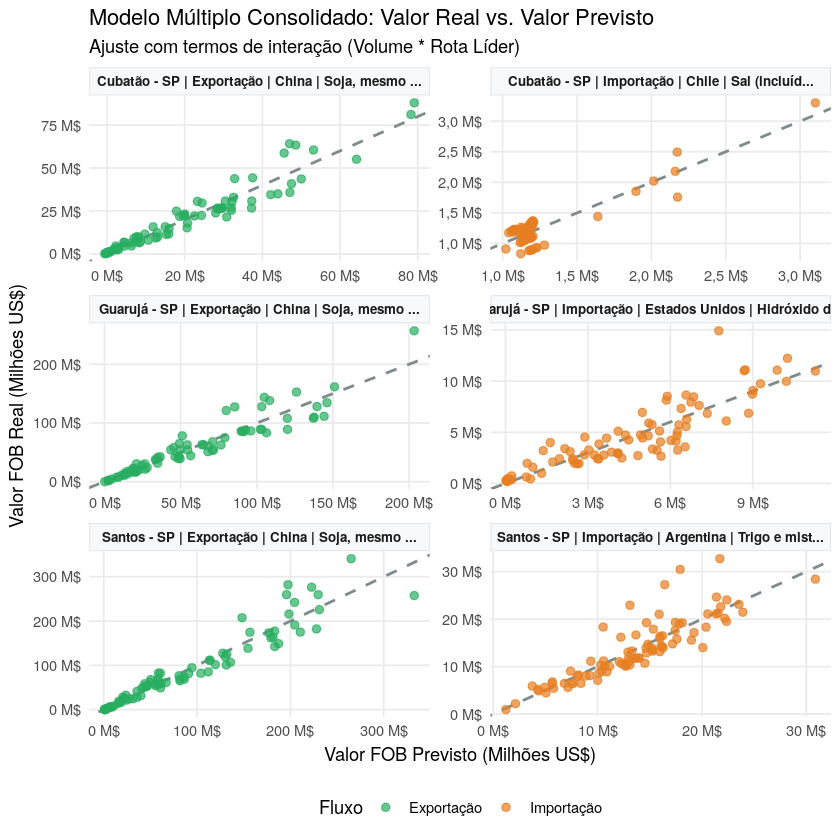

In [11]:
# 3. Diagnóstico gráfico facetado
plotar_diagnostico_multipla(regressao_multipla)

## 3. Teste Formal de Heterocedasticidade: Breusch-Pagan

O formato de cone observado no gráfico de resíduos sugere a presença de heterocedasticidade (variância residual não constante ao longo do volume). Para validar formalmente essa violação dos pressupostos OLS, aplica-se o **Teste de Breusch-Pagan**:

* **Hipótese Nula ($H_0$):** $\sigma_i^2 = \sigma^2$ (Homocedasticidade — variância dos resíduos é constante).
* **Hipótese Alternativa ($H_1$):** $\sigma_i^2 = f(X_i)$ (Heterocedasticidade presente).
* **Critério de Decisão:** Rejeita-se $H_0$ se o $p\text{-valor} < 0{,}05$.

In [12]:
# Execução do Teste de Breusch-Pagan
teste_bp <- executar_teste_breusch_pagan(regressao_simples, regressao_multipla)

# 1. Resultados para as 6 Regressões Simples
cat("--- TESTE DE BREUSCH-PAGAN: REGRESSÕES SIMPLES ---\n")
as.data.frame(teste_bp$simples)

# 2. Resultado para a Regressão Múltipla Consolidada
cat("\n--- TESTE DE BREUSCH-PAGAN: REGRESSÃO MÚLTIPLA CONSOLIDADA ---\n")
as.data.frame(teste_bp$multiplo)

--- TESTE DE BREUSCH-PAGAN: REGRESSÕES SIMPLES ---


Rota,BP Estatística (LM),Graus de Liberdade,p-valor,Diagnóstico (α = 5%)
<chr>,<dbl>,<dbl>,<chr>,<chr>
Cubatão - SP | Exportação | China,26.05,1,<0.001,Heterocedástico
Guarujá - SP | Exportação | China,28.84,1,<0.001,Heterocedástico
Santos - SP | Exportação | China,34.42,1,<0.001,Heterocedástico
Cubatão - SP | Importação | Chile,6.62,1,0.0101,Heterocedástico
Guarujá - SP | Importação | Estados Unidos,4.64,1,0.0313,Heterocedástico
Santos - SP | Importação | Argentina,2.98,1,0.0842,Homocedástico



--- TESTE DE BREUSCH-PAGAN: REGRESSÃO MÚLTIPLA CONSOLIDADA ---


Modelo,BP Estatística (LM),Graus de Liberdade,p-valor,Diagnóstico (α = 5%)
<chr>,<dbl>,<dbl>,<chr>,<chr>
Múltiplo Consolidado (Interações),223,11,<0.001,Heterocedástico


### Análise e Interpretação do Teste de Breusch-Pagan

* **Constatação Estatística:** Com exceção da rota de importação de trigo em Santos ($p = 0{,}0842$), todas as demais rotas simples e o modelo múltiplo consolidado apresentaram $p\text{-valor} < 0{,}05$, rejeitando a hipótese nula ($H_0$) de homocedasticidade.
* **Justificativa Econômica:** A heterocedasticidade reflete a dinâmica de grandes volumes de comércio exterior: à medida que os carregamentos aumentam (escala de navios graneleiros), a volatilidade do faturamento absoluto em dólares também se expande em virtude das oscilações de preço de frete, câmbio e cotações internacionais de commodities.
* **Implicação Metodológica:** Os coeficientes de inclinação ($\beta_1$, preço médio por tonelada) permanecem consistentes, mas a variância crescente dos resíduos confirma a relevância do diagnóstico gráfico de dispersão em cone.